In [2]:

! pip install shap
! pip install pycaret
! pip install seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn import datasets, svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn import set_config
from sklearn.utils import resample
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc

In [4]:
file_path =r'c:\Users\user\Downloads\BREAST1 (1).csv'
file_path

'c:\\Users\\user\\Downloads\\BREAST1 (1).csv'

In [5]:
df= pd.read_csv(file_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309044 entries, 0 to 309043
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Sex                     309044 non-null  object
 1   Age                     309044 non-null  object
 2   Race                    309044 non-null  object
 3   Marital status          309044 non-null  object
 4   ER                      309044 non-null  object
 5   HER2                    309044 non-null  object
 6   PR                      309044 non-null  object
 7   T/N/M Stage             309044 non-null  object
 8   Behavior code           309044 non-null  object
 9   Sequence number         309044 non-null  object
 10  Chemotherapy            309044 non-null  object
 11  Mets all                309044 non-null  object
 12  Mets at bone            309044 non-null  object
 13  Mets at brain           309044 non-null  object
 14  Mets at liver           309044 non-n

In [6]:
# profiling
import pandas as pd
import ydata_profiling
pr = df.profile_report() # 프로파일링 결과 리포트를 pr에 저장
pr.to_file('./df_report.html') # pr_report.html 파일로 저장

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 24/24 [00:00<00:00, 154.73it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [7]:
import pandas as pd
import numpy as np
import re

In [8]:
if df.empty:
    raise ValueError("데이터프레임이 비어 있습니다. 파일을 다시 확인하세요.")


In [9]:
print(df.columns)

Index(['Sex', 'Age', 'Race', 'Marital status', 'ER', 'HER2', 'PR',
       'T/N/M Stage', 'Behavior code', 'Sequence number', 'Chemotherapy',
       'Mets all', 'Mets at bone', 'Mets at brain', 'Mets at liver',
       'Mets at lung', 'Radiation', 'Surgery Oth Reg/Dis', 'Surgery Prim Site',
       'Rural-Urban', 'cancer treatment delay', 'Income', 'Survival months',
       'Cancer Site'],
      dtype='object')


In [10]:
# Therapy 컬럼 전처리
# 1. Surgery Prim Site_binary + Surgery_Reg_Group= Surgery_Combined
# 2. Radiation_binary
# 3. Chemo_Binary
# 3개 변수의 조합 = 8개 클래스 형성 후 [0,1,2,3,4,5,6,7]로 라벨링


# Surgery Prim Site_binary
df['Surgery Prim Site_binary'] = df['Surgery Prim Site'].apply(lambda x: 0 if x == 0 else 1)

# Surgery_Reg_Group
def surgery_other_group(value):
    if value in ['0', 'None; diagnosed at autopsy', 'Unknown; death certificate only']:
        return 0
    elif value in [
        'Non-primary surgical procedure performed',
        'Non-primary surgical procedure to other regional sites',
        'Non-primary surgical procedure to distant site',
        'Non-primary surgical procedure to distant lymph node(s)',
        'Any combo of sur proc to oth rg, dis lym nd, and/or dis site'
    ]:
        return 1
    else:
        return None

df['Surgery_Reg_Group'] = df['Surgery Oth Reg/Dis'].apply(surgery_other_group)
df = df[df['Surgery_Reg_Group'].notna()]

# Radiation_binary
df['Radiation_binary'] = df['Radiation'].apply(lambda x: 0 if x in ["None/Unknown", "Refused (1988+)", "Recommended, unknown if administered"] else 1)

# Chemo_Binary
def chemo_binary(value):
    if value == 'No/Unknown':
        return 0
    elif value == 'Yes':
        return 1
    else:
        return None

df['Chemo_Binary'] = df['Chemotherapy'].apply(chemo_binary)
df = df[df['Chemo_Binary'].notna()]

# Surgery_Combined
df['Surgery_Combined'] = ((df['Surgery Prim Site_binary']==1) | (df['Surgery_Reg_Group']==1)).astype(int)

# Therapy target (0~7)
mapping = {
    (0,0,0):0, (0,0,1):1, (0,1,0):2, (1,0,0):3,
    (0,1,1):4, (1,0,1):5, (1,1,0):6, (1,1,1):7
}
df['target'] = df[['Surgery_Combined','Radiation_binary','Chemo_Binary']].apply(lambda row: mapping[tuple(row)], axis=1)
print("Target value counts:\n", df['target'].value_counts().sort_index())

Target value counts:
 target
0     12552
1     10609
2      1095
3     82781
4      2618
5     35143
6    100365
7     63881
Name: count, dtype: int64


In [11]:
import pandas as pd

# 타겟 변수 빈도와 비율 계산
target_counts = df['target'].value_counts().sort_index()
target_ratio = target_counts / target_counts.sum() * 100

# 표(DataFrame) 만들기
target_summary = pd.DataFrame({
    "빈도": target_counts,
    "비율(%)": target_ratio.round(2)
})

target_summary

,빈도,비율(%)
target,,
0,12552,4.06
1,10609,3.43
2,1095,0.35
3,82781,26.79
4,2618,0.85
5,35143,11.37
6,100365,32.48
7,63881,20.67


In [12]:
# 타겟 제외 모든 변수 전처리


# Income 처리
def extract_min_income_safe(x):
    try:
        if pd.isna(x):
            return None
        if '+' in x:
            return int(x.replace('$','').replace(',','').replace('+',''))
        elif '<' in x:
            return int(x.replace('$','').replace(',','').replace('<','')) // 2
        elif '-' in x:
            parts = x.replace('$','').replace(',','').split(' - ')
            return (int(parts[0]) + int(parts[1])) // 2
        else:
            return int(x.replace('$','').replace(',',''))
    except:
        return None

df['Income_num'] = df['Income'].apply(extract_min_income_safe)

def income_group(x):
    if x is None:
        return None
    elif x < 55000:
        return 'LOW'
    elif 55000 <= x <= 89999:
        return 'MIDDLE'
    else:
        return 'HIGH'

df['Income_group'] = df['Income_num'].apply(income_group)
income_mapping = {'LOW':1, 'MIDDLE':2, 'HIGH':3, None:0}
df['Income_code'] = df['Income_group'].map(income_mapping)

# Race 그룹핑
if 'Race' in df.columns:
    df['Race_grouped'] = df['Race'].replace({
        'Unknown':'Other (Unknown/AIAN)',
        'American Indian/Alaska Native':'Other (Unknown/AIAN)'
    }).fillna('Other (Unknown/AIAN)')

# 기존 그룹핑 코드 아래에 추가
if 'Race_grouped' in df.columns:
    df['Race_grouped'] = df['Race_grouped'].astype('category').cat.codes


# Marital status 그룹핑
if 'Marital status' in df.columns:
    marital_map = {
        'Married (including common law)': 'Married',
        'Divorced': 'Previously Married',
        'Separated': 'Previously Married',
        'Widowed': 'Previously Married',
        'Never married': 'Single/Other',
        'Unknown': 'Single/Other',
        'Unmarried or Domestic Partner': 'Single/Other'
    }
    df['Marital_group'] = df['Marital status'].replace(marital_map).fillna('Single/Other')

# 기존 그룹핑 코드 아래에 추가
if 'Marital_group' in df.columns:
    df['Marital_group'] = df['Marital_group'].astype('category').cat.codes


# Rural-Urban 그룹핑
def group_urban_rural_keep_unknown(x):
    if pd.isna(x) or 'unknown' in str(x).lower():
        return 'Unknown'
    s = str(x)
    if 'Large Metro' in s or 'Large metro' in s or 'Large ' in s:
        return 'Large metro'
    if 'metropolitan areas of' in s or 'Small' in s or 'Medium' in s:
        return 'Small/Medium metro'
    return 'Rural'

if 'Rural-Urban' in df.columns:
    df['Rural-Urban_grouped'] = df['Rural-Urban'].apply(group_urban_rural_keep_unknown)

# 기존 그룹핑 코드 아래에 추가
if 'Rural-Urban_grouped' in df.columns:
    df['Rural-Urban_grouped'] = df['Rural-Urban_grouped'].astype('category').cat.codes


# Stage_Number 추출
def extract_stage_number(stage):
    match = re.search(r'(\d)', str(stage))
    return int(match.group(1)) if match else 0

df['Stage_Number'] = df['T/N/M Stage'].apply(extract_stage_number) if 'T/N/M Stage' in df.columns else 0

# Sequence number 기반 파생
if 'Sequence number' in df.columns:
    df['One_vs_Other'] = df['Sequence number'].apply(lambda x: 1 if str(x) == "One primary only" else 0)
    def first_vs_later_safe(value):
        if value == 'One primary only':
            return -1
        elif value == '1st of 2 or more primaries':
            return 1
        else:
            return 0
    df['First_vs_Later'] = df['Sequence number'].apply(first_vs_later_safe)
else:
    df['One_vs_Other'] = 0
    df['First_vs_Later'] = 0

# cancer treatment delay 처리
df['cancer treatment delay'] = df['cancer treatment delay'].replace('Unable to calculate','Unknown')
df['cancer treatment delay_num'] = pd.to_numeric(df['cancer treatment delay'], errors='coerce')
def categorize_delay(x):
    if pd.isna(x):
        return 3
    elif 0 <= x <= 30:
        return 0
    elif 31 <= x <= 60:
        return 1
    elif x >= 61:
        return 2
    else:
        return 3
df['cancer_delay_label'] = df['cancer treatment delay_num'].apply(categorize_delay)
df.loc[df['cancer treatment delay']=='Unknown','cancer_delay_label'] = 3

# 주요 binary 변수 변환
binary_cols = ['Sex','ER','PR','HER2','Mets at bone','Mets at brain','Mets at liver','Mets at lung']
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: 1 if any(k in str(x).lower() for k in ['yes','positive','female','malignant','1']) else 0)
    else:
        df[col] = 0

# Age ordinal
if 'Age' in df.columns:
    try:
        age_cats = sorted(df['Age'].dropna().unique())
        age_map = {cat:i for i,cat in enumerate(age_cats)}
        df['Age_ord'] = df['Age'].map(age_map).fillna(0).astype(int)
    except:
        df['Age_ord'] = 0
else:
    df['Age_ord'] = 0

# Behavior code
def behavior_insitu_flag(x):
    s = str(x).strip().lower()
    if 'in situ' in s or 'insitu' in s:
        return 1
    if 'malignant' in s:
        return 0
    return np.nan
if 'Behavior code' in df.columns:
    df['Behavior_is_insitu'] = df['Behavior code'].apply(behavior_insitu_flag).fillna(0).astype(int)
else:
    df['Behavior_is_insitu'] = 0



In [13]:
print(df.columns)

Index(['Sex', 'Age', 'Race', 'Marital status', 'ER', 'HER2', 'PR',
       'T/N/M Stage', 'Behavior code', 'Sequence number', 'Chemotherapy',
       'Mets all', 'Mets at bone', 'Mets at brain', 'Mets at liver',
       'Mets at lung', 'Radiation', 'Surgery Oth Reg/Dis', 'Surgery Prim Site',
       'Rural-Urban', 'cancer treatment delay', 'Income', 'Survival months',
       'Cancer Site', 'Surgery Prim Site_binary', 'Surgery_Reg_Group',
       'Radiation_binary', 'Chemo_Binary', 'Surgery_Combined', 'target',
       'Income_num', 'Income_group', 'Income_code', 'Race_grouped',
       'Marital_group', 'Rural-Urban_grouped', 'Stage_Number', 'One_vs_Other',
       'First_vs_Later', 'cancer treatment delay_num', 'cancer_delay_label',
       'Age_ord', 'Behavior_is_insitu'],
      dtype='object')


In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 중복 + 불필요한 칼럼 제거

drop_cols = [
    # 원본 + 중복 컬럼
    'Age', 'Behavior code', 'Cancer Site', 'Mets all',
    'cancer treatment delay','cancer treatment delay_num',
    'Surgery Prim Site', 'Surgery Oth Reg/Dis', 'Radiation',
    'Chemotherapy',
    # Target/therapy 관련 컬럼
    'Surgery Prim Site_binary', 'Surgery_Reg_Group', 'Radiation_binary',
    'Chemo_Binary', 'Surgery_Combined',
    # 전처리 중복 컬럼
    'Income', 
    # 원본 컬럼 제거(전처리 컬럼 남기기)
    'Marital status', 'Race', 'Rural-Urban', 'T/N/M Stage', 'Sequence number','Income_num', 'Income_group', 'labeling'
]

# x/y 분리
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df['target']

#범주형 -> 숫자 변환
for col in X.select_dtypes('category').columns:
    X[col] = X[col].cat.codes

#  결측값 0으로 채우기
X = X.fillna(0)


print("X shape:", X.shape)
print("Columns:", X.columns.tolist())
print("y unique values:", np.unique(y))



X shape: (309044, 20)
Columns: ['Sex', 'ER', 'HER2', 'PR', 'Mets at bone', 'Mets at brain', 'Mets at liver', 'Mets at lung', 'Survival months', 'target', 'Income_code', 'Race_grouped', 'Marital_group', 'Rural-Urban_grouped', 'Stage_Number', 'One_vs_Other', 'First_vs_Later', 'cancer_delay_label', 'Age_ord', 'Behavior_is_insitu']
y unique values: [0 1 2 3 4 5 6 7]


In [15]:
# X에서 target 제거
X = X.drop(columns=['target'])

# y는 target 그대로 사용
y = df['target']

print("X shape:", X.shape)
print("Columns:", X.columns.tolist())
print("y unique values:", np.unique(y))


X shape: (309044, 19)
Columns: ['Sex', 'ER', 'HER2', 'PR', 'Mets at bone', 'Mets at brain', 'Mets at liver', 'Mets at lung', 'Survival months', 'Income_code', 'Race_grouped', 'Marital_group', 'Rural-Urban_grouped', 'Stage_Number', 'One_vs_Other', 'First_vs_Later', 'cancer_delay_label', 'Age_ord', 'Behavior_is_insitu']
y unique values: [0 1 2 3 4 5 6 7]


In [16]:
print(X.dtypes)


Sex                    int64
ER                     int64
HER2                   int64
PR                     int64
Mets at bone           int64
Mets at brain          int64
Mets at liver          int64
Mets at lung           int64
Survival months        int64
Income_code            int64
Race_grouped            int8
Marital_group           int8
Rural-Urban_grouped     int8
Stage_Number           int64
One_vs_Other           int64
First_vs_Later         int64
cancer_delay_label     int64
Age_ord                int32
Behavior_is_insitu     int32
dtype: object


In [17]:
print(X.head())
print(y.head())


   Sex  ER  HER2  PR  Mets at bone  Mets at brain  Mets at liver  \
0    1   0     0   0             0              0              0   
1    1   1     0   1             0              0              0   
2    1   1     0   1             0              0              0   
3    1   1     0   1             0              0              0   
4    1   1     0   1             0              0              0   

   Mets at lung  Survival months  Income_code  Race_grouped  Marital_group  \
0             0               59            3             3              2   
1             0               52            3             3              1   
2             0               38            3             3              2   
3             0               49            3             0              1   
4             0               13            3             0              0   

   Rural-Urban_grouped  Stage_Number  One_vs_Other  First_vs_Later  \
0                    0             2             0  

In [18]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [25]:
from sklearn.preprocessing import LabelEncoder


# 오버샘플링 적용
# 범주형 컬럼 자동 탐색
cat_cols = X.select_dtypes(include='object').columns.tolist()

# Label Encoding
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# 결측값은 0으로 채우기
X = X.fillna(0)

# SMOTE 적용
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("After SMOTE -> X:", X_res.shape, ", y:", np.unique(y_res, return_counts=True))


After SMOTE -> X: (802920, 19) , y: (array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int64), array([100365, 100365, 100365, 100365, 100365, 100365, 100365, 100365],
      dtype=int64))


In [26]:
# Train/Test split (80/20, shuffle=True, stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res,
    test_size=0.2,
    random_state=42,
    stratify=y_res,
    shuffle=True
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (642336, 19)
X_test shape: (160584, 19)


In [27]:
# RandomForest 학습
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [28]:
# 예측 및 평가
y_pred = rf.predict(X_test)

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Confusion Matrix ===
[[17949   361   146   660   144   176   418   219]
 [  270 17825   239   174   487   411   201   466]
 [   49    40 19740    22   173    10    25    14]
 [ 1434   409   145  8593    41  1858  5781  1812]
 [   35   209   261    17 19480    24    20    27]
 [  357   894    82  1340   135 12858  1545  2862]
 [  843   265   120  5420    36  1678  9425  2286]
 [  425   994    85  1642   151  3200  2556 11020]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.84      0.89      0.87     20073
           1       0.85      0.89      0.87     20073
           2       0.95      0.98      0.97     20073
           3       0.48      0.43      0.45     20073
           4       0.94      0.97      0.96     20073
           5       0.64      0.64      0.64     20073
           6       0.47      0.47      0.47     20073
           7       0.59      0.55      0.57     20073

    accuracy                           0.73    

In [29]:
#5-Fold Stratified Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_res, y_res, cv=cv, scoring='f1_weighted')

print("\n5-Fold CV F1 Score (weighted):", cv_scores)
print("Mean CV F1 Score:", cv_scores.mean())


5-Fold CV F1 Score (weighted): [0.72385628 0.72363017 0.72364343 0.72317903 0.72330649]
Mean CV F1 Score: 0.7235230805613776


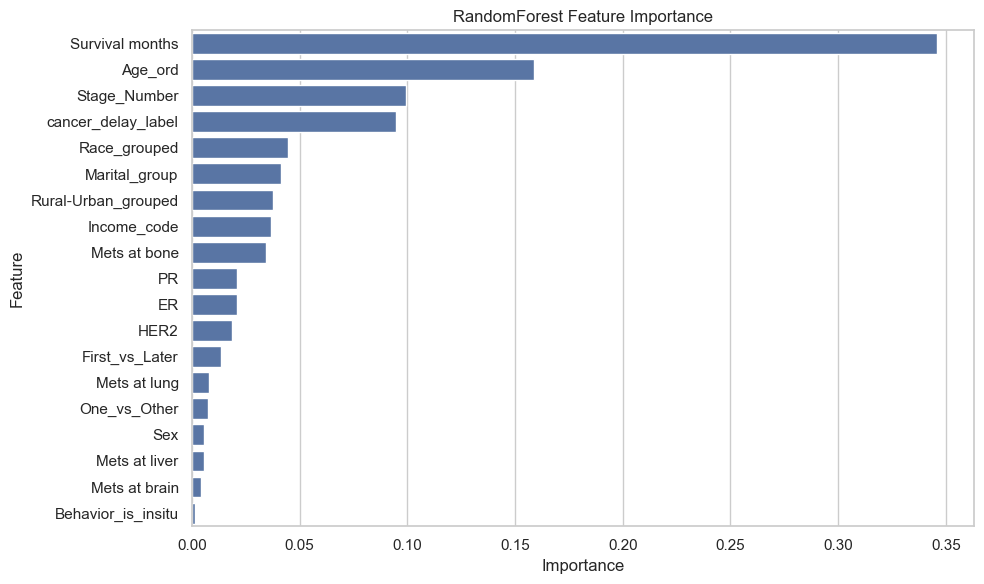

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature importance 추출
importances = rf.feature_importances_
feat_names = X_train.columns
feat_imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# 시각화
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df)
plt.title('RandomForest Feature Importance')
plt.tight_layout()
plt.show()


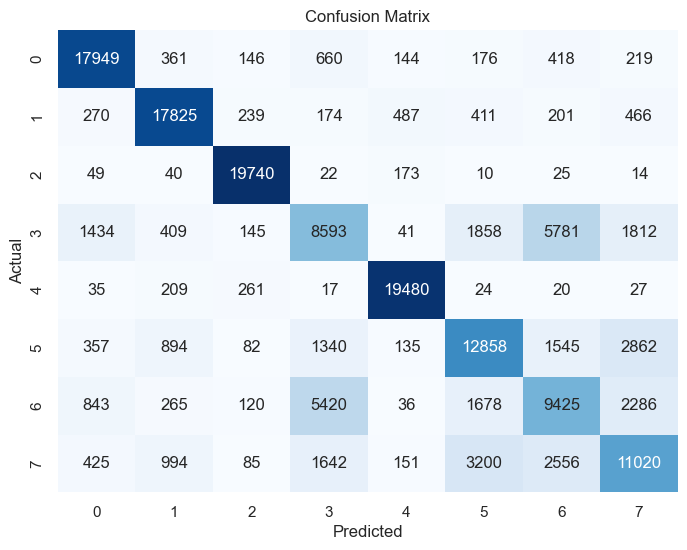

In [31]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [32]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_int('max_depth', 3, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    
    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(clf, X_res, y_res, cv=cv, scoring='f1_weighted')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)  # 30회 반복 최적화

print("Best trial:")
trial = study.best_trial
print(f"  F1 Score: {trial.value}")
print("  Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


[I 2025-09-03 15:36:47,206] A new study created in memory with name: no-name-7a947450-cf98-4e14-8eca-ea49b6dd0742
[I 2025-09-03 15:40:24,795] Trial 0 finished with value: 0.5904376106390694 and parameters: {'n_estimators': 410, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 7, 'max_features': None}. Best is trial 0 with value: 0.5904376106390694.
[I 2025-09-03 15:41:48,406] Trial 1 finished with value: 0.5257717975086245 and parameters: {'n_estimators': 162, 'max_depth': 12, 'min_samples_split': 17, 'min_samples_leaf': 20, 'max_features': None}. Best is trial 0 with value: 0.5904376106390694.
[I 2025-09-03 15:42:27,060] Trial 2 finished with value: 0.6656212454361565 and parameters: {'n_estimators': 158, 'max_depth': 21, 'min_samples_split': 14, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 2 with value: 0.6656212454361565.
[I 2025-09-03 15:42:40,430] Trial 3 finished with value: 0.45889021301615196 and parameters: {'n_estimators': 79, 'max_depth': 6, 'min

Best trial:
  F1 Score: 0.7250803653227224
  Params:
    n_estimators: 179
    max_depth: 30
    min_samples_split: 5
    min_samples_leaf: 1
    max_features: log2


In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

# Optuna 최적 하이퍼파라미터 불러오기
best_params = study.best_trial.params
print("Best Params:", best_params)

# 최적 파라미터로 모델 학습
clf_best = RandomForestClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1
)
clf_best.fit(X_train, y_train)  # Train 데이터 학습

# Test 데이터 예측
y_pred = clf_best.predict(X_test)

# Test 성능 지표 확인
print(" Classification Report (Test Data)")
print(classification_report(y_test, y_pred))

f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print(" Test Metrics (weighted)")
print(f"F1 Score    : {f1:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")



Best Params: {'n_estimators': 179, 'max_depth': 30, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2'}
 Classification Report (Test Data)
              precision    recall  f1-score   support

           0       0.84      0.88      0.86     20073
           1       0.85      0.88      0.86     20073
           2       0.95      0.98      0.97     20073
           3       0.49      0.43      0.46     20073
           4       0.94      0.97      0.96     20073
           5       0.63      0.63      0.63     20073
           6       0.48      0.51      0.49     20073
           7       0.59      0.55      0.57     20073

    accuracy                           0.73    160584
   macro avg       0.72      0.73      0.72    160584
weighted avg       0.72      0.73      0.72    160584

 Test Metrics (weighted)
F1 Score    : 0.7248
Precision   : 0.7224
Recall      : 0.7282


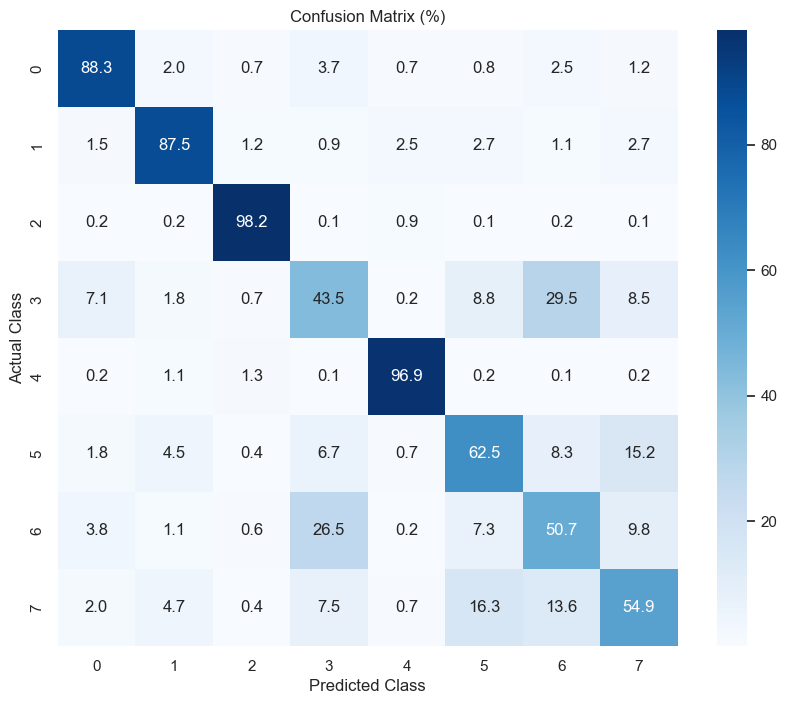

In [34]:
#import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Confusion Matrix 계산
cm = confusion_matrix(y_test, y_pred)
labels = np.unique(y_test)

# 비율로 변환 
cm_ratio = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 시각화
plt.figure(figsize=(10,8))
sns.heatmap(cm_ratio, annot=True, fmt=".1f", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix (%)")
plt.show()




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



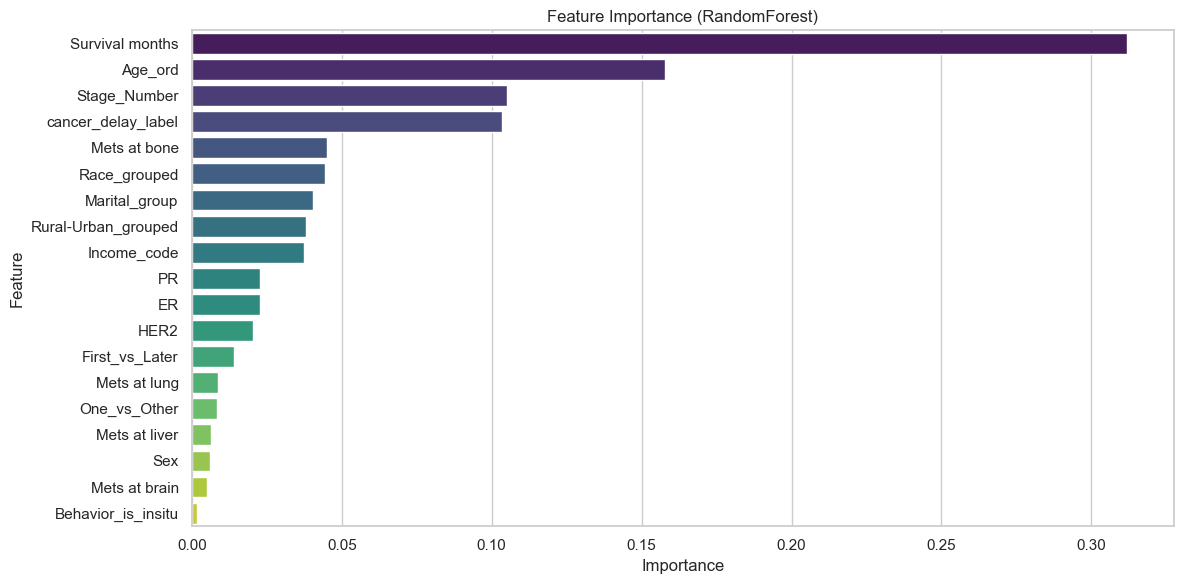

In [35]:
# Feature Importance 시각화

importances = clf_best.feature_importances_
indices = np.argsort(importances)[::-1]  # 중요도 순서대로 정렬
features = X_train.columns

plt.figure(figsize=(12,6))
sns.barplot(x=importances[indices], y=features[indices], palette="viridis")
plt.title("Feature Importance (RandomForest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



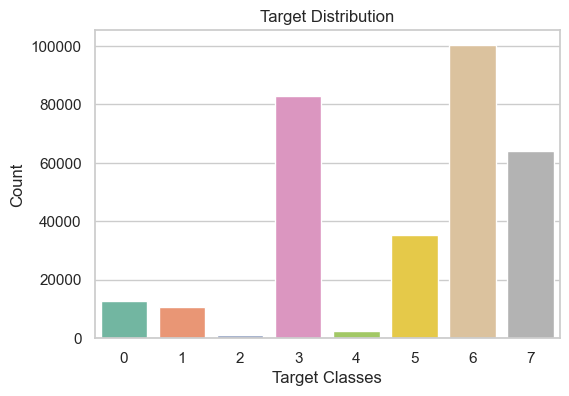

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


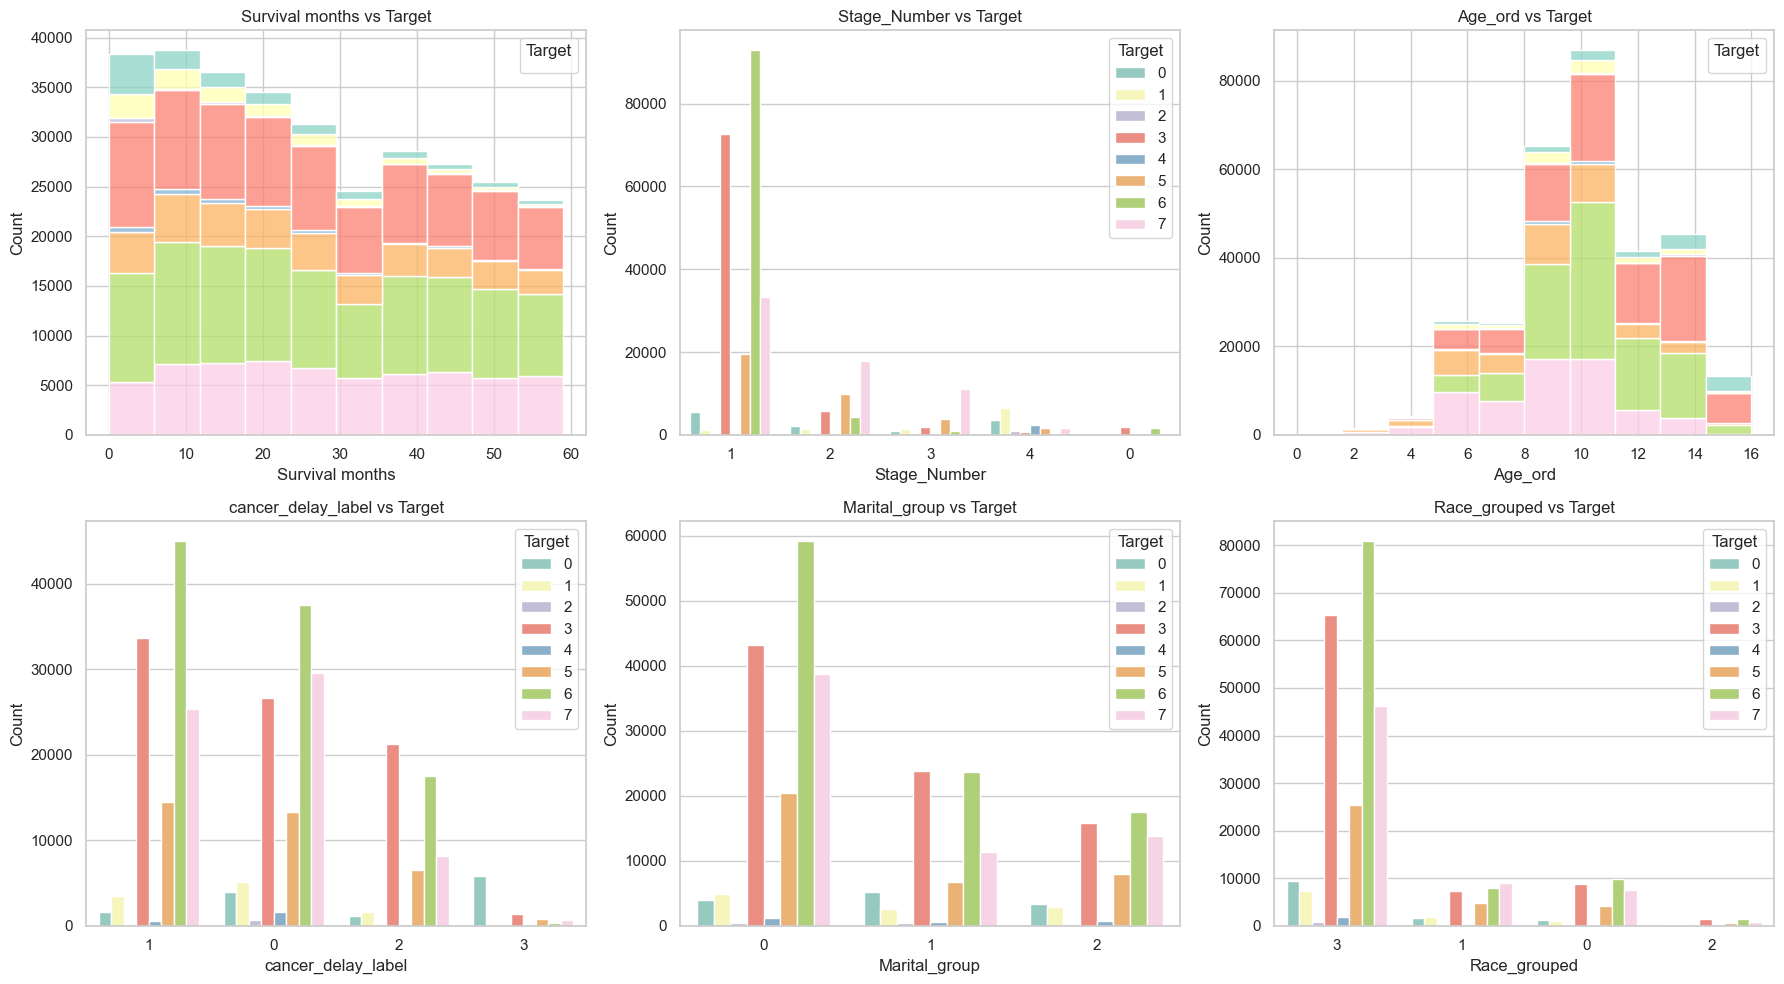

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set(style="whitegrid")

# ===== 1) 타겟 분포 확인 =====
plt.figure(figsize=(6,4))
sns.countplot(x=y, palette="Set2")
plt.title("Target Distribution")
plt.xlabel("Target Classes")
plt.ylabel("Count")
plt.show()



# ===== 2) 타겟 vs 주요 변수 6개 시각화 (2x3) =====
top_vars = ['Survival months', 'Stage_Number', 'Age_ord', 'cancer_delay_label', 'Marital_group', 'Race_grouped']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
ax = axes.ravel()

for i, col in enumerate(top_vars):
    if col not in df.columns:
        print(f"⚠ Warning: '{col}' column not in DataFrame")
        continue
    
    # 범주형 변수: countplot, 수치형 변수: 히스토그램
    if df[col].dtype == 'object' or len(df[col].unique()) <= 10:
        order = df[col].value_counts().index
        sns.countplot(x=col, hue=y, data=df, order=order, ax=ax[i], palette="Set3")
        ax[i].set_xlabel(col)
    else:
        sns.histplot(data=df, x=col, hue=y, multiple="stack", bins=10, ax=ax[i], palette="Set3")
        ax[i].set_xlabel(col)
    
    ax[i].set_ylabel("Count")
    ax[i].set_title(f"{col} vs Target")
    ax[i].legend(title='Target', loc='best')

plt.tight_layout()
plt.show()



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



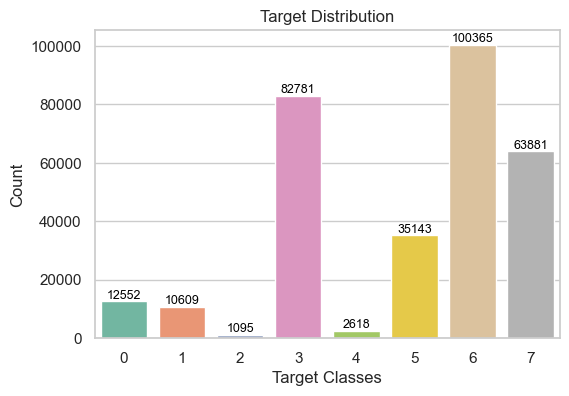

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



=== Histogram counts for Survival months ===
target            0     1    2      3    4     5      6     7
bin                                                          
(-0.059, 5.9]  4000  2402  404  10633  496  4111  10938  5353
(5.9, 11.8]    1920  2003  186   9937  530  4772  12254  7186
(11.8, 17.7]   1578  1517  126   9641  391  4257  11800  7270
(17.7, 23.6]   1200  1184  110   8925  292  3938  11423  7429
(23.6, 29.5]   1018  1078   73   8526  276  3671   9880  6765
(29.5, 35.4]    790   708   64   6689  197  2943   7411  5750
(35.4, 41.3]    694   651   36   7886  138  3168   9863  6178
(41.3, 47.2]    522   454   33   7327  130  2979   9565  6315
(47.2, 53.1]    480   344   36   6946   88  2855   8962  5725
(53.1, 59.0]    350   268   27   6271   80  2449   8269  5910


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



=== Count Table for Stage_Number ===
target           0     1    2      3     4      5      6      7
Stage_Number                                                   
0              156    10    1   1954     0    106   1647     50
1             5552  1118   98  72569    59  19590  92994  33365
2             2204  1551   35   5784    67   9956   4438  17744
3             1074  1366   87   1848   118   3896   1042  11008
4             3566  6564  874    626  2374   1595    244   1714


The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



=== Histogram counts for Age_ord ===
target            0     1    2      3    4     5      6      7
bin                                                           
(-0.016, 1.6]     0     0    0      3    0     3      0      8
(1.6, 3.2]       34   113    0    158   29   481     66    696
(3.2, 4.8]       84   294   10    448   71  1251    228   1799
(4.8, 6.4]      469  1142   52   4547  296  5620   3913   9594
(6.4, 8.0]     1017  1910  108  11713  536  8487  15816  15938
(8.0, 9.6]      764  1353  106   6734  349  4670  12061   8986
(9.6, 11.2]    2305  2871  247  19759  726  8587  35414  17098
(11.2, 12.8]   1366  1209  141  13475  280  3193  16166   5682
(12.8, 14.4]   3196  1347  236  19244  269  2581  14569   3856
(14.4, 16.0]   3317   370  195   6700   62   270   2132    224

=== Count Table for cancer_delay_label ===
target                 0     1    2      3     4      5      6      7
cancer_delay_label                                                   
0                   39

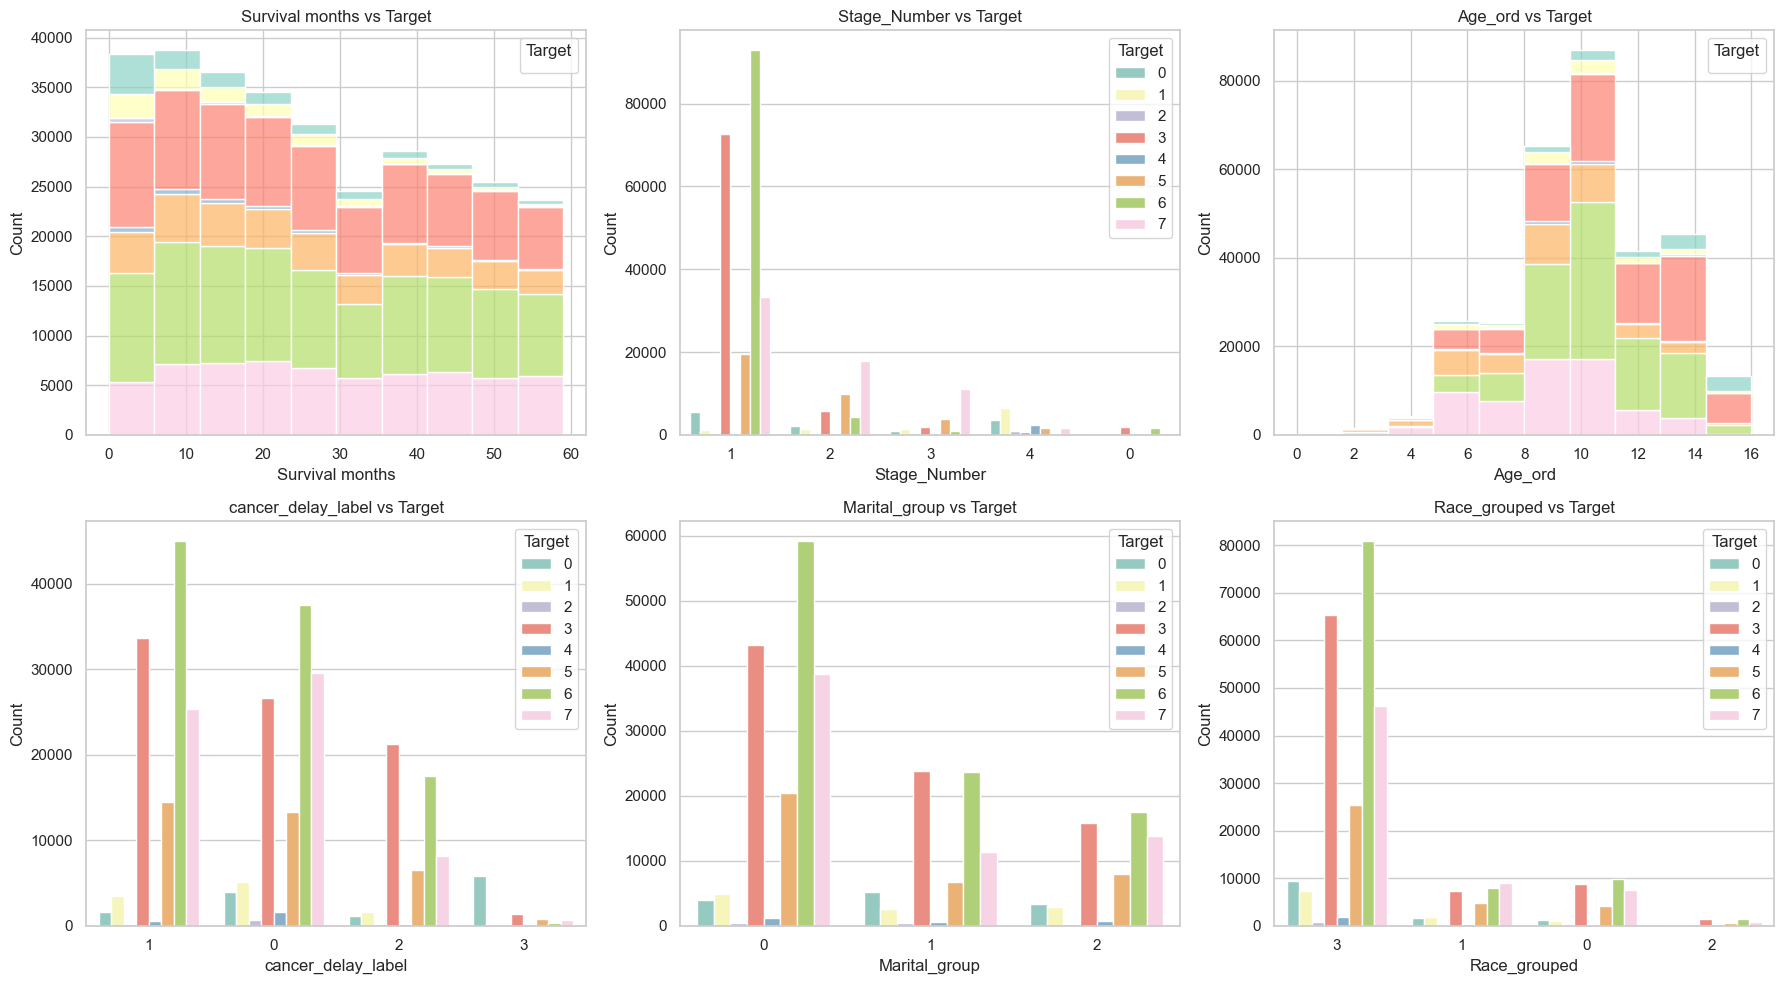

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set(style="whitegrid")

# ===== 1) 타겟 분포 확인 =====
plt.figure(figsize=(6,4))
ax = sns.countplot(x=y, palette="Set2")
plt.title("Target Distribution")
plt.xlabel("Target Classes")
plt.ylabel("Count")

# 막대 위에 값 표기 (이 부분은 타겟 분포는 간단해서 직접 표시)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom', fontsize=9, color='black')

plt.show()


# ===== 2) 타겟 vs 주요 변수 6개 시각화 (2x3) =====
top_vars = ['Survival months', 'Stage_Number', 'Age_ord', 
            'cancer_delay_label', 'Marital_group', 'Race_grouped']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
ax = axes.ravel()

for i, col in enumerate(top_vars):
    if col not in df.columns:
        print(f"⚠ Warning: '{col}' column not in DataFrame")
        continue
    
    # --- 범주형 변수 ---
    if df[col].dtype == 'object' or len(df[col].unique()) <= 10:
        order = df[col].value_counts().index
        sns.countplot(x=col, hue=y, data=df, order=order, ax=ax[i], palette="Set3")
        ax[i].set_xlabel(col)
        ax[i].set_ylabel("Count")
        ax[i].set_title(f"{col} vs Target")
        ax[i].legend(title='Target', loc='best')

        # 값은 따로 출력
        counts = df.groupby([col, y]).size().unstack(fill_value=0)
        print(f"\n=== Count Table for {col} ===")
        print(counts)

    # --- 수치형 변수 ---
    else:
        # 히스토그램 (겹치지 않게 투명도 사용)
        sns.histplot(data=df, x=col, hue=y, multiple="stack", bins=10, ax=ax[i], palette="Set3", alpha=0.7)
        ax[i].set_xlabel(col)
        ax[i].set_ylabel("Count")
        ax[i].set_title(f"{col} vs Target")
        ax[i].legend(title='Target', loc='upper right')

        # 값은 따로 출력
        bin_groups = pd.cut(df[col], bins=10)
        hist_vals = df.assign(bin=bin_groups, target=y).groupby(['bin','target']).size().unstack(fill_value=0)
        print(f"\n=== Histogram counts for {col} ===")
        print(hist_vals)

plt.tight_layout()
plt.show()



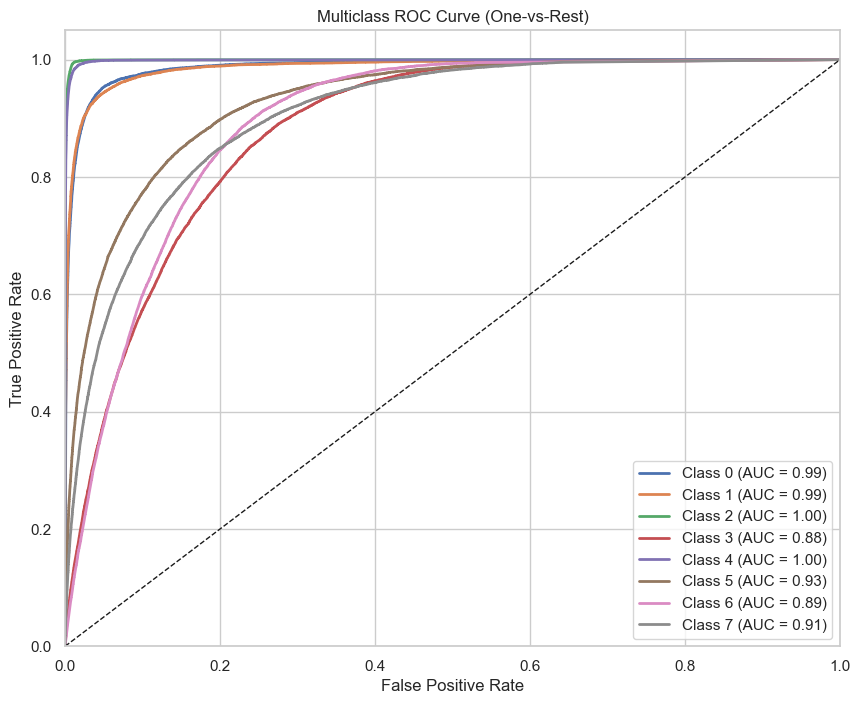

In [38]:

# 다중 클래스 ROC Curve (One-vs-Rest)

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt

# 타겟 클래스 이진화 (One-vs-Rest)
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

# One-vs-Rest 방식으로 예측 확률 계산
ovr_clf = OneVsRestClassifier(clf_best)
y_score = ovr_clf.fit(X_train, y_train).predict_proba(X_test)

# 클래스별 ROC Curve 계산
plt.figure(figsize=(10, 8))
for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"Class {class_label} (AUC = {roc_auc:.2f})")

# 대각선 기준선 추가
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [39]:

# 필수 라이브러리

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, accuracy_score, average_precision_score
)

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier


# 데이터 준비 (SMOTE 후 train/test 분리)

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, stratify=y_res, random_state=42
)


# 모델 리스트 정의

models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(n_estimators=200, random_state=42,
                                 use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1),
    "LightGBM": lgb.LGBMClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostClassifier(n_estimators=200, random_state=42, verbose=0)
}


# 모델 학습 + 평가

results = []

for name, model in models.items():
    print(f"\n=== {name} ===")
    
    # 학습
    model.fit(X_train, y_train)
    
    # Test 예측
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)  # 다중분류 확률
    
    #  주요 지표 계산
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    
    roc_auc_ovr = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
    roc_auc_ovo = roc_auc_score(y_test, y_proba, multi_class='ovo', average='macro')
    pr_auc = average_precision_score(y_test, y_proba, average='macro')
    
    #  Classification Report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    #  Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)
    
    #  주요 성능 출력
    print(f"Accuracy     : {acc:.4f}")
    print(f"Macro F1     : {macro_f1:.4f}")
    print(f"Weighted F1  : {weighted_f1:.4f}")
    print(f"ROC-AUC (OVR): {roc_auc_ovr:.4f}")
    print(f"ROC-AUC (OVO): {roc_auc_ovo:.4f}")
    print(f"PR-AUC       : {pr_auc:.4f}")
    
    # 결과 저장
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Macro_F1": macro_f1,
        "Weighted_F1": weighted_f1,
        "ROC_AUC_OVR": roc_auc_ovr,
        "ROC_AUC_OVO": roc_auc_ovo,
        "PR_AUC": pr_auc
    })


# 성능 비교표

results_df = pd.DataFrame(results)
print("\n=== Model Comparison ===")
print(results_df.sort_values(by="Macro_F1", ascending=False))




=== RandomForest ===
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87     20073
           1       0.85      0.89      0.87     20073
           2       0.95      0.98      0.97     20073
           3       0.48      0.43      0.46     20073
           4       0.94      0.97      0.96     20073
           5       0.64      0.64      0.64     20073
           6       0.47      0.47      0.47     20073
           7       0.59      0.55      0.57     20073

    accuracy                           0.73    160584
   macro avg       0.72      0.73      0.72    160584
weighted avg       0.72      0.73      0.72    160584

Confusion Matrix:
[[17946   363   146   651   145   170   433   219]
 [  280 17817   235   176   479   431   204   451]
 [   46    41 19742    21   173    11    24    15]
 [ 1443   397   144  8636    39  1845  5763  1806]
 [   34   206   262    17 19480    26    17    31]
 [  352   882    82  1344   136

[16:59:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.



Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.69      0.73     20073
           1       0.64      0.50      0.56     20073
           2       0.78      0.86      0.82     20073
           3       0.42      0.42      0.42     20073
           4       0.74      0.82      0.77     20073
           5       0.47      0.44      0.46     20073
           6       0.46      0.60      0.52     20073
           7       0.46      0.42      0.44     20073

    accuracy                           0.59    160584
   macro avg       0.59      0.59      0.59    160584
weighted avg       0.59      0.59      0.59    160584

Confusion Matrix:
[[13779   924  1003  1949   673   366   902   477]
 [  547 10011  1554   505  3352  1991   343  1770]
 [  281   480 17279   338  1236    97   212   150]
 [ 1661   272   251  8340    41  1676  6576  1256]
 [   48  1292  1529    49 16423   286    50   396]
 [  415  1391   234  1987   305  8898  2430  4413]
 [

In [40]:
pip install tabulate

Note: you may need to restart the kernel to use updated packages.


In [41]:

#  성능 비교표 (DataFrame 출력)

import pandas as pd
from tabulate import tabulate  

results_df = pd.DataFrame(results)

# Macro_F1 기준 정렬
results_df = results_df.sort_values(by="Macro_F1", ascending=False).reset_index(drop=True)

print("\n=== Model Comparison ===")
print(tabulate(results_df, headers='keys', tablefmt='pretty', showindex=False))



=== Model Comparison ===
+--------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|    Model     |      Accuracy      |      Macro_F1      |    Weighted_F1     |    ROC_AUC_OVR     |    ROC_AUC_OVO     |       PR_AUC       |
+--------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
| RandomForest | 0.7281734170278483 | 0.7237286845860658 | 0.7237286845860657 | 0.9433714571049324 | 0.9433714571049323 | 0.7604158674464518 |
|   XGBoost    | 0.5926306481343098 | 0.5902938649934739 | 0.590293864993474  | 0.9119964382939763 | 0.9119964382939763 | 0.6309671367575993 |
|   CatBoost   | 0.5624283863896776 | 0.5599146300341107 | 0.5599146300341107 | 0.9020138503841029 | 0.9020138503841029 | 0.5942544243093206 |
|   LightGBM   | 0.5610147959946197 | 0.5587021201706892 | 0.5587021201706892 | 0.9029957798644621 | 0.9029957798644

In [42]:

# 라이브러리 불러오기

import optuna
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# 데이터 준비 (SMOTE 후 train/test)

# X_res, y_res가 SMOTE로 이미 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, stratify=y_res, random_state=42
)


# Optuna 튜닝 함수 정의


def tune_model(model_name, X, y, n_trials=20):
    def objective(trial):
        if model_name == "RandomForest":
            clf = RandomForestClassifier(
                n_estimators=trial.suggest_int('n_estimators', 50, 500),
                max_depth=trial.suggest_int('max_depth', 3, 30),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 20),
                max_features=trial.suggest_categorical('max_features', ['sqrt','log2',None]),
                random_state=42,
                n_jobs=-1
            )
        elif model_name == "XGBoost":
            clf = xgb.XGBClassifier(
                n_estimators=trial.suggest_int('n_estimators', 50, 500),
                max_depth=trial.suggest_int('max_depth', 3, 30),
                learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
                subsample=trial.suggest_float('subsample', 0.6, 1.0),
                colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
                random_state=42,
                use_label_encoder=False,
                eval_metric='mlogloss',
                n_jobs=-1
            )
        elif model_name == "LightGBM":
            clf = lgb.LGBMClassifier(
                n_estimators=trial.suggest_int('n_estimators', 50, 500),
                max_depth=trial.suggest_int('max_depth', 3, 30),
                learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
                num_leaves=trial.suggest_int('num_leaves', 20, 150),
                subsample=trial.suggest_float('subsample', 0.6, 1.0),
                colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
                random_state=42,
                n_jobs=-1
            )
        elif model_name == "CatBoost":
            clf = CatBoostClassifier(
                iterations=trial.suggest_int('iterations', 100, 500),
                depth=trial.suggest_int('depth', 3, 10),
                learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
                l2_leaf_reg=trial.suggest_float('l2_leaf_reg', 1, 10),
                random_state=42,
                verbose=0
            )
        else:
            raise ValueError("Unsupported model")
        
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(clf, X, y, cv=cv, scoring='f1_weighted')
        return scores.mean()
    
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    print(f"\n[{model_name}] Best trial:")
    print(f"  F1 Score: {study.best_trial.value:.4f}")
    print("  Params:", study.best_trial.params)
    
    return study.best_trial.params


# 모델별 최적 하이퍼파라미터 찾기

best_params_dict = {}
for model_name in ["RandomForest", "XGBoost", "LightGBM", "CatBoost"]:
    best_params_dict[model_name] = tune_model(model_name, X_res, y_res, n_trials=20)


# 최적 모델 학습 + Test 평가

results = []

for model_name, params in best_params_dict.items():
    if model_name == "RandomForest":
        model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    elif model_name == "XGBoost":
        model = xgb.XGBClassifier(**params, random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1)
    elif model_name == "LightGBM":
        model = lgb.LGBMClassifier(**params, random_state=42, n_jobs=-1)
    elif model_name == "CatBoost":
        model = CatBoostClassifier(**params, random_state=42, verbose=0)
    
    # 학습
    model.fit(X_train, y_train)
    
    # Test 예측
    y_pred = model.predict(X_test)
    
    # 지표 계산
    f1 = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    
    results.append({
        "Model": model_name,
        "F1_weighted": f1,
        "Precision_weighted": precision,
        "Recall_weighted": recall
    })
    
    # 출력
    print(f"\n[{model_name}] Test Classification Report")
    print(classification_report(y_test, y_pred))

# 모델 성능 비교표

results_df = pd.DataFrame(results)
print("\n=== Model Comparison ===")
print(results_df.sort_values(by="F1_weighted", ascending=False))


[I 2025-09-03 17:00:04,844] A new study created in memory with name: no-name-558184e3-6f4e-4fec-9ae0-de3f150d2694


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-09-03 17:00:52,558] Trial 0 finished with value: 0.453484956018703 and parameters: {'n_estimators': 369, 'max_depth': 5, 'min_samples_split': 16, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.453484956018703.
[I 2025-09-03 17:01:50,525] Trial 1 finished with value: 0.5432866301053291 and parameters: {'n_estimators': 291, 'max_depth': 14, 'min_samples_split': 2, 'min_samples_leaf': 16, 'max_features': 'log2'}. Best is trial 1 with value: 0.5432866301053291.
[I 2025-09-03 17:03:07,298] Trial 2 finished with value: 0.4648265196553251 and parameters: {'n_estimators': 496, 'max_depth': 7, 'min_samples_split': 12, 'min_samples_leaf': 11, 'max_features': 'log2'}. Best is trial 1 with value: 0.5432866301053291.
[I 2025-09-03 17:04:11,124] Trial 3 finished with value: 0.5523376091643761 and parameters: {'n_estimators': 309, 'max_depth': 14, 'min_samples_split': 12, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 3 with value: 0.5523376091643

[I 2025-09-03 17:38:17,269] A new study created in memory with name: no-name-e08036a1-100a-41aa-b20b-862aa38eec62


[I 2025-09-03 17:38:17,267] Trial 19 finished with value: 0.6668197196911898 and parameters: {'n_estimators': 432, 'max_depth': 20, 'min_samples_split': 13, 'min_samples_leaf': 7, 'max_features': None}. Best is trial 15 with value: 0.6973979450932826.

[RandomForest] Best trial:
  F1 Score: 0.6974
  Params: {'n_estimators': 484, 'max_depth': 25, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': None}


...

[I 2025-09-03 20:59:51,799] Trial 19 finished with value: 0.6013098283809241 and parameters: {'n_estimators': 411, 'max_depth': 24, 'learning_rate': 0.09253599536524076, 'num_leaves': 38, 'subsample': 0.9478491259810282, 'colsample_bytree': 0.9028648503677155}. Best is trial 11 with value: 0.6439177338599615.

[LightGBM] Best trial:
  F1 Score: 0.6439
  Params: {'n_estimators': 171, 'max_depth': 15, 'learning_rate': 0.12611174687928425, 'num_leaves': 148, 'subsample': 0.9029163556638944, 'colsample_bytree': 0.85124368742175}


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-09-03 21:04:11,083] Trial 0 finished with value: 0.6011446914709515 and parameters: {'iterations': 140, 'depth': 10, 'learning_rate': 0.23007499437546391, 'l2_leaf_reg': 5.5648542953420845}. Best is trial 0 with value: 0.6011446914709515.
[I 2025-09-03 21:05:26,174] Trial 1 finished with value: 0.47842831114593914 and parameters: {'iterations': 201, 'depth': 3, 'learning_rate': 0.07856747520299749, 'l2_leaf_reg': 9.509166913717703}. Best is trial 0 with value: 0.6011446914709515.
[I 2025-09-03 21:06:47,579] Trial 2 finished with value: 0.4929824727083319 and parameters: {'iterations': 219, 'depth': 3, 'learning_rate': 0.17064657525430652, 'l2_leaf_reg': 4.691517765074613}. Best is trial 0 with value: 0.6011446914709515.
[I 2025-09-03 21:08:59,803] Trial 3 finished with value: 0.5158959738857354 and parameters: {'iterations': 301, 'depth': 6, 'learning_rate': 0.07091674190842494, 'l2_leaf_reg': 3.6458777330909813}. Best is trial 0 with value: 0.6011446914709515.
[I 2025-09-03 21

[23:02:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




[XGBoost] Test Classification Report
              precision    recall  f1-score   support

           0       0.86      0.90      0.88     20073
           1       0.88      0.90      0.89     20073
           2       0.95      0.98      0.97     20073
           3       0.50      0.45      0.47     20073
           4       0.95      0.97      0.96     20073
           5       0.67      0.66      0.67     20073
           6       0.48      0.51      0.50     20073
           7       0.63      0.57      0.60     20073

    accuracy                           0.74    160584
   macro avg       0.74      0.74      0.74    160584
weighted avg       0.74      0.74      0.74    160584

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017611 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[Ligh

In [46]:
print(results_df.columns)

Index(['Model', 'F1_weighted', 'Precision_weighted', 'Recall_weighted'], dtype='object')


In [51]:
print(results_df.columns.tolist())
for col in results_df.columns:
    print(repr(col))


['Model', 'Weighted_F1', 'Weighted_Precision', 'Weighted_Recall']
'Model'
'Weighted_F1'
'Weighted_Precision'
'Weighted_Recall'


In [52]:
results_df.columns = results_df.columns.str.strip()

In [55]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import roc_auc_score, average_precision_score
import pandas as pd

# 결과 저장용 리스트
results = []

for model_name, model in models.items():  # models = {"RF": rf_model, "LGBM": lgbm_model, ...}
    y_pred = model.predict(X_test)
    
    # 다중분류에서는 확률 예측 필요
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
    else:
        y_proba = None

    # 지표 계산
    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average='weighted')
    prec_w = precision_score(y_test, y_pred, average='weighted')
    rec_w = recall_score(y_test, y_pred, average='weighted')
    
    # ROC, PR AUC (다중분류용 OVR 방식)
    roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr") if y_proba is not None else None
    pr_auc = average_precision_score(y_test, y_proba, average="weighted") if y_proba is not None else None

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "F1_weighted": f1_w,
        "Precision_weighted": prec_w,
        "Recall_weighted": rec_w,
        "ROC_AUC_OVR": roc_auc,
        "PR_AUC": pr_auc
    })

# DataFrame 변환
results_df = pd.DataFrame(results)
print(results_df)


          Model  Accuracy  F1_weighted  Precision_weighted  Recall_weighted  \
0  RandomForest  0.700319     0.696755            0.695796         0.700319   
1       XGBoost  0.744016     0.741190            0.739419         0.744016   
2      LightGBM  0.644759     0.642327            0.645238         0.644759   
3      CatBoost  0.661934     0.659503            0.661118         0.661934   

   ROC_AUC_OVR    PR_AUC  
0     0.941770  0.741895  
1     0.952840  0.781074  
2     0.927364  0.686015  
3     0.931559  0.700739  



=== Model Comparison Table ===
╒══════════════╤════════════╤═══════════════╤══════════════════════╤═══════════════════╤═══════════════╤══════════╕
│ Model        │   Accuracy │   F1_weighted │   Precision_weighted │   Recall_weighted │   ROC_AUC_OVR │   PR_AUC │
╞══════════════╪════════════╪═══════════════╪══════════════════════╪═══════════════════╪═══════════════╪══════════╡
│ RandomForest │     0.7003 │        0.6968 │               0.6958 │            0.7003 │        0.9418 │   0.7419 │
├──────────────┼────────────┼───────────────┼──────────────────────┼───────────────────┼───────────────┼──────────┤
│ XGBoost      │     0.7440 │        0.7412 │               0.7394 │            0.7440 │        0.9528 │   0.7811 │
├──────────────┼────────────┼───────────────┼──────────────────────┼───────────────────┼───────────────┼──────────┤
│ LightGBM     │     0.6448 │        0.6423 │               0.6452 │            0.6448 │        0.9274 │   0.6860 │
├──────────────┼────────────┼───────────

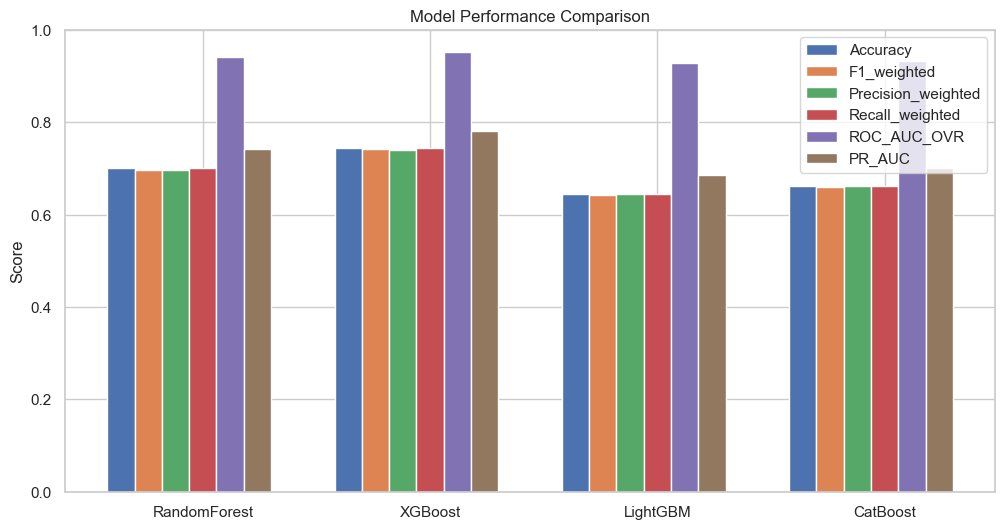

In [57]:
from tabulate import tabulate
import matplotlib.pyplot as plt

# 컬럼명 정리
results_df.columns = results_df.columns.str.strip()

# 콘솔 출력
print("\n=== Model Comparison Table ===")
print(tabulate(results_df, headers='keys', tablefmt='fancy_grid', showindex=False, floatfmt=".4f"))

# 막대그래프
plt.figure(figsize=(12,6))
bar_width = 0.12
index = range(len(results_df))

metrics = ["Accuracy", "F1_weighted", "Precision_weighted", "Recall_weighted", "ROC_AUC_OVR", "PR_AUC"]

for i, metric in enumerate(metrics):
    if metric in results_df.columns:  # 실제 있는 컬럼만 그림
        plt.bar([x + bar_width*i - bar_width*3 for x in index],
                results_df[metric],
                width=bar_width,
                label=metric)

plt.xticks(index, results_df['Model'])
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.show()



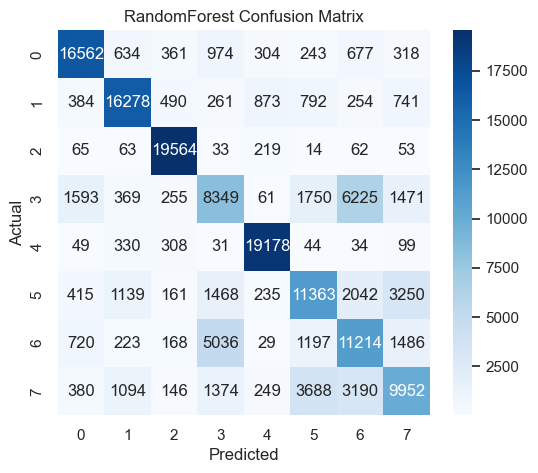

[09:51:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.



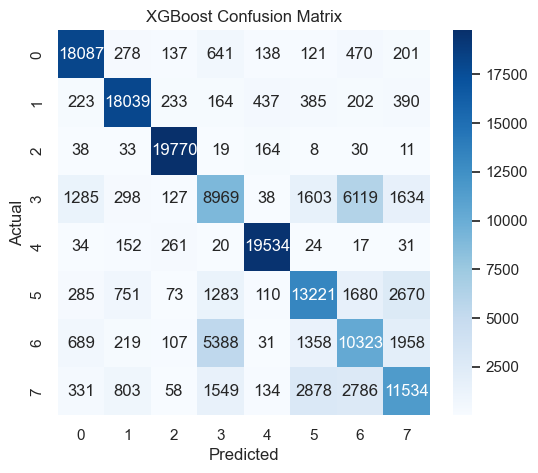

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015257 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 124
[LightGBM] [Info] Number of data points in the train set: 642336, number of used features: 19
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442


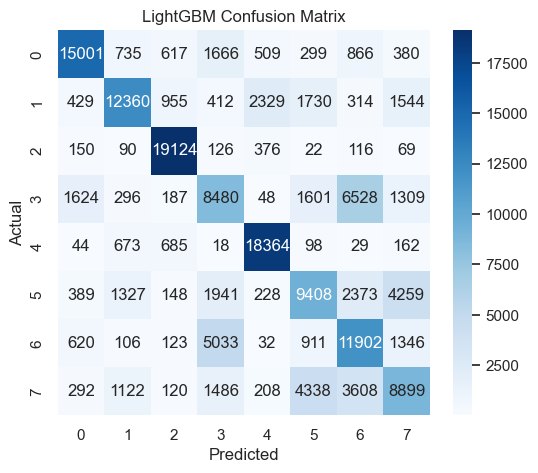

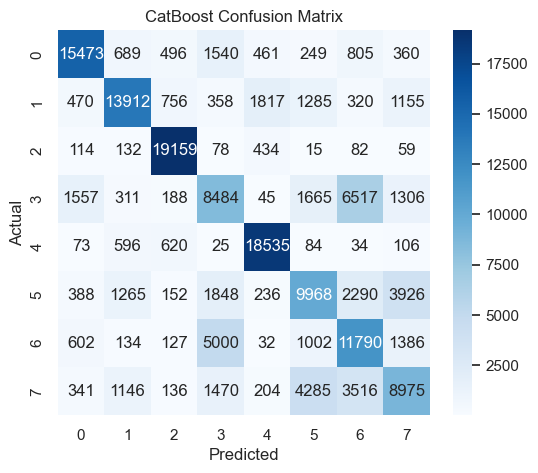


=== Multi-class Model Comparison (Weighted F1 기준) ===
          Model  Weighted_F1  Weighted_Precision  Weighted_Recall
0       XGBoost     0.741190            0.739419         0.744016
1  RandomForest     0.696755            0.695796         0.700319
2      CatBoost     0.659503            0.661118         0.661934
3      LightGBM     0.642327            0.645238         0.644759


In [48]:

#  라이브러리 불러오기

import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 모델 리스트와 이미 학습된 모델(best_params 기반)
models = {
    "RandomForest": RandomForestClassifier(**best_params_dict["RandomForest"], random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(**best_params_dict["XGBoost"], random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1),
    "LightGBM": lgb.LGBMClassifier(**best_params_dict["LightGBM"], random_state=42, n_jobs=-1),
    "CatBoost": CatBoostClassifier(**best_params_dict["CatBoost"], random_state=42, verbose=0)
}


#  모델 학습 + Test 예측 + 지표 계산

results = []

for name, model in models.items():
    # 학습
    model.fit(X_train, y_train)
    
    # 예측
    y_pred = model.predict(X_test)
    
    # 지표 계산
    f1_w = f1_score(y_test, y_pred, average='weighted')
    precision_w = precision_score(y_test, y_pred, average='weighted')
    recall_w = recall_score(y_test, y_pred, average='weighted')
    
    results.append({
        "Model": name,
        "Weighted_F1": f1_w,
        "Weighted_Precision": precision_w,
        "Weighted_Recall": recall_w
    })
    
    # Confusion Matrix 시각화
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


#  결과 비교표

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Weighted_F1", ascending=False).reset_index(drop=True)
print("\n=== Multi-class Model Comparison (Weighted F1 기준) ===")
print(results_df)


In [ ]:
# 필수 라이브러리 임포트
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

# Train/Test 데이터 준비 (이미 나눠져 있다고 가정)
# X_train, X_test, y_train, y_test

# 최적 파라미터 적용
best_params = {
    "RandomForest": {
        "n_estimators": 399,
        "max_depth": 25,
        "min_samples_split": 16,
        "min_samples_leaf": 1,
        "max_features": None,
        "random_state": 42
    },
    "XGBoost": {
        "n_estimators": 442,
        "max_depth": 21,
        "learning_rate": 0.05320739278646658,
        "subsample": 0.9376388921884038,
        "colsample_bytree": 0.7367896287537983,
        "random_state": 42,
        "use_label_encoder": False,
        "eval_metric": "mlogloss"
    },
    "LightGBM": {
        "n_estimators": 498,
        "max_depth": 11,
        "learning_rate": 0.10899659504297245,
        "num_leaves": 73,
        "subsample": 0.7190357281695148,
        "colsample_bytree": 0.9145974959035617,
        "random_state": 42
    },
    "CatBoost": {
        "iterations": 470,
        "depth": 10,
        "learning_rate": 0.21882014225422447,
        "l2_leaf_reg": 3.0597346132689114,
        "verbose": 0,
        "random_state": 42
    }
}

# 모델 생성
models = {
    "RandomForest": RandomForestClassifier(**best_params["RandomForest"]),
    "XGBoost": XGBClassifier(**best_params["XGBoost"]),
    "LightGBM": LGBMClassifier(**best_params["LightGBM"]),
    "CatBoost": CatBoostClassifier(**best_params["CatBoost"])
}

# 결과 저장용 데이터프레임
results = pd.DataFrame(columns=["Model", "F1_weighted", "Precision_weighted", "Recall_weighted"])

# 학습 및 평가
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    f1 = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    
    results = pd.concat([results, pd.DataFrame([{
        "Model": name,
        "F1_weighted": f1,
        "Precision_weighted": precision,
        "Recall_weighted": recall
    }])], ignore_index=True)

# 결과 출력 (F1 기준 내림차순)
print(results.sort_values(by="F1_weighted", ascending=False))


The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
[12:25:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

Could not find the number of physical cores for the following reason:
[WinError 2] 지정된 파일을 찾을 수 없습니다
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  File "c:\Users\user\anaconda3\envs\python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\user\anaconda3\envs\python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\user\anaconda3\env

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018053 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 124
[LightGBM] [Info] Number of data points in the train set: 642336, number of used features: 19
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
          Model  F1_weighted  Precision_weighted  Recall_weighted
1       XGBoost     0.741443            0.740212         0.743928
0  

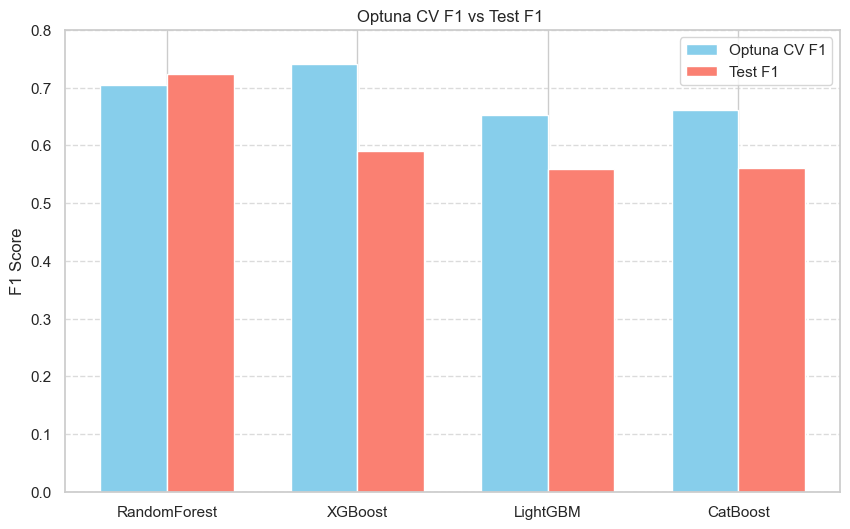

In [ ]:

# 라이브러리 불러오기

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 데이터 준비

data = {
    "Model": ["RandomForest", "XGBoost", "LightGBM", "CatBoost"],
    "Optuna_CV_F1": [0.7045, 0.7409, 0.6530, 0.6616],
    "Test_F1": [0.7237, 0.5903, 0.5587, 0.5599]
}

df = pd.DataFrame(data)


#시각화

plt.figure(figsize=(10,6))
bar_width = 0.35
index = range(len(df))

# Optuna CV F1
plt.bar(index, df['Optuna_CV_F1'], bar_width, label='Optuna CV F1', color='skyblue')

# Test F1
plt.bar([i + bar_width for i in index], df['Test_F1'], bar_width, label='Test F1', color='salmon')

# X축 레이블
plt.xticks([i + bar_width/2 for i in index], df['Model'])
plt.ylim(0, 0.8)
plt.ylabel("F1 Score")
plt.title("Optuna CV F1 vs Test F1 ")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
import pandas as pd


# 데이터 준비

data = {
    "Model": ["RandomForest", "XGBoost", "LightGBM", "CatBoost"],
    "Optuna_CV_F1": [0.7045, 0.7409, 0.6530, 0.6616],
    "Test_F1": [0.7237, 0.5903, 0.5587, 0.5599]
}

df = pd.DataFrame(data)


# VS Code 콘솔에서 표로 출력

print("\n=== 모델별 Optuna CV F1 vs Test F1 ===")
print(df)


=== 모델별 Optuna CV F1 vs Test F1 ===
          Model  Optuna_CV_F1  Test_F1
0  RandomForest        0.7045   0.7237
1       XGBoost        0.7409   0.5903
2      LightGBM        0.6530   0.5587
3      CatBoost        0.6616   0.5599
